# Racial Equity in U.S. Grantmaking — Findings

**Research question:** Within private-foundation grantmaking, what share of grants advances
racial equity, who funds it, where does it go, and what issues does it support?

**Data:** Individual grant records parsed from IRS Form **990-PF** e-file XML, pulled from two
IRS release archives (2020 and 2023) so the sample spans fiscal years ~2018–2022, enriched with
the ProPublica Nonprofit Explorer API. Grants are flagged as racial-equity-related by a keyword
classifier on the grant-purpose text, following the spirit of
[Candid / PRE methodology](https://blog.candid.org/post/what-counts-as-racial-equity-funding/)
(`src/data_cleaning.py`).

**Sampling caveat (important).** This uses a *convenience sample* — the first N filings from each
archive, not a random draw. Funder/geography/issue patterns and especially any year-over-year
comparison are therefore dominated by which large funders happen to appear in the sample, and
should be read as **method demonstration, not representative estimates**. A representative result
needs random sampling across all chunks of many release years.

---

In [1]:
import sys
sys.path.insert(0, '..')
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt, matplotlib.image as mpimg
from src.data_cleaning import get_connection

%matplotlib inline
plt.rcParams['figure.dpi'] = 130
PROC = Path('../data/processed')
conn = get_connection(Path('../data/racial_equity_grants.sqlite'))

## Key statistics

In [2]:
s = pd.read_sql("""
    SELECT COUNT(*) AS total_grants,
           COUNT(DISTINCT funder_ein) AS unique_funders,
           COUNT(DISTINCT recipient_name) AS unique_recipients,
           ROUND(SUM(grant_amount)/1e6, 2) AS total_dollars_m,
           ROUND(AVG(grant_amount)) AS avg_grant_size,
           MIN(tax_year) AS first_yr, MAX(tax_year) AS last_yr
    FROM grants WHERE is_racial_equity = 1
""", conn).iloc[0]

overall = pd.read_sql('SELECT COUNT(*) n, SUM(grant_amount) amt FROM grants', conn).iloc[0]
share_n = s.total_grants / overall.n
share_amt = (s.total_dollars_m * 1e6) / overall.amt

print(f"""
Fiscal years in sample:      {int(s.first_yr)}–{int(s.last_yr)}
Racial equity grants:        {s.total_grants:,}  ({share_n:.1%} of all grants)
Racial equity dollars:       ${s.total_dollars_m:,.1f}M  ({share_amt:.1%} of all grant $)
Average RE grant size:       ${s.avg_grant_size:,.0f}
Funders making RE grants:    {s.unique_funders:,}
Distinct RE recipients:      {s.unique_recipients:,}
""")


Fiscal years in sample:      2018–2022
Racial equity grants:        359.0  (0.6% of all grants)
Racial equity dollars:       $58.9M  (3.1% of all grant $)
Average RE grant size:       $163,927
Funders making RE grants:    30.0
Distinct RE recipients:      285.0



> Consistent with Candid's published finding that funding explicitly coded to racial/ethnic
> communities has long hovered around ~9–12% of U.S. giving, racial-equity-tagged grants are a
> **small slice** of overall foundation grantmaking in this sample.

## Finding 1: Racial equity giving is highly concentrated among a few funders

A Herfindahl-Hirschman Index (HHI) above 0.25 signals high concentration.

In [3]:
re_grants = pd.read_sql('SELECT * FROM grants WHERE is_racial_equity=1', conn)
shares = re_grants.groupby('funder_ein')['grant_amount'].sum()
hhi = ((shares / shares.sum()) ** 2).sum()
print(f"RE funders: {shares.size} | HHI: {hhi:.3f} | "
      f"top {min(5, shares.size)} = {shares.nlargest(5).sum()/shares.sum():.1%} of RE dollars")

pd.read_sql("""
    SELECT COALESCE(f.name, g.funder_ein) AS funder, f.state,
           COUNT(*) AS grants, ROUND(SUM(g.grant_amount)/1e6,2) AS dollars_m
    FROM grants g LEFT JOIN foundations f ON g.funder_ein=f.ein
    WHERE g.is_racial_equity=1
    GROUP BY g.funder_ein ORDER BY SUM(g.grant_amount) DESC LIMIT 10
""", conn)

RE funders: 30 | HHI: 0.592 | top 5 = 99.7% of RE dollars


,funder,state,grants,dollars_m
0,WK KELLOGG FOUNDATION,MI,107,42.48
1,THE CALIFORNIA ENDOWMENT,CA,219,15.68
2,FIRST REPUBLIC FOUNDATION,CA,2,0.25
3,CHUCK LORRE FAMILY FOUNDATION,CA,1,0.13
4,LELAND FIKES FOUNDATION INC,TX,1,0.10
5,METROWEST HEALTH FOUNDATION INC,MA,3,0.05
6,THE BUHL FOUNDATION,PA,1,0.03
7,THE RAYMOND DEBBANE FAMILY FOUNDATION,NY,1,0.03
8,TOWBES FOUNDATION,CA,1,0.01
9,THE SOPHRON FOUNDATION,VA,1,0.01


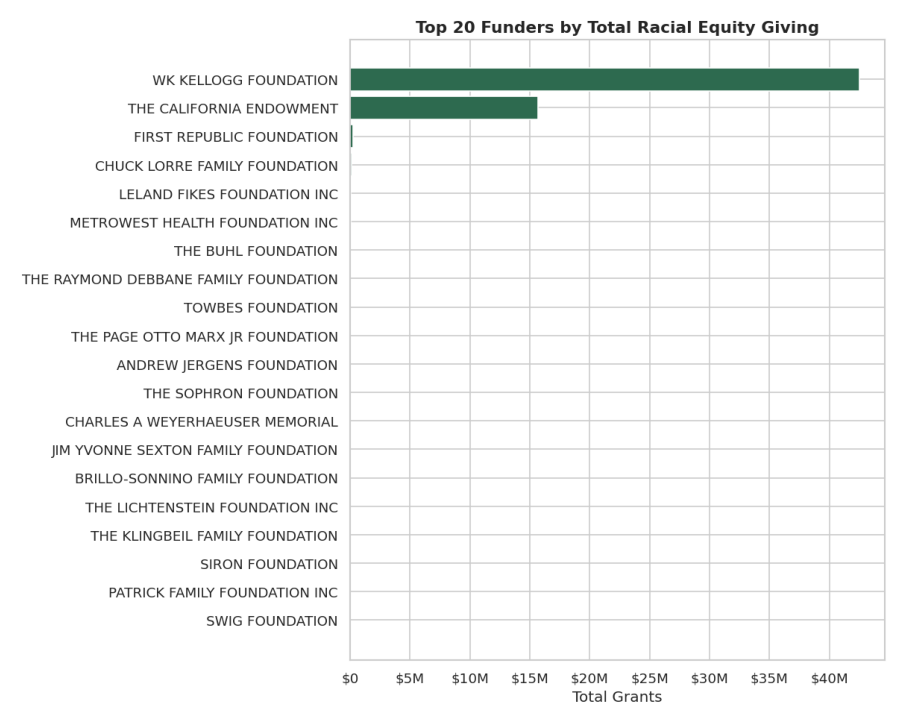

In [4]:
p = PROC / 'fig_top_funders.png'
if p.exists():
    plt.figure(figsize=(10, 7)); plt.imshow(mpimg.imread(p)); plt.axis('off'); plt.show()
else:
    print('Run Notebook 03 to generate fig_top_funders.png')

## Finding 2: Recipients cluster geographically

In [5]:
pd.read_sql("""
    SELECT recipient_state, COUNT(*) AS grants, ROUND(SUM(grant_amount)/1e6,2) AS dollars_m
    FROM grants WHERE is_racial_equity=1 AND recipient_state IS NOT NULL
    GROUP BY recipient_state ORDER BY SUM(grant_amount) DESC LIMIT 10
""", conn)

,recipient_state,grants,dollars_m
0,CA,217,18.30
1,DC,22,6.10
2,NY,25,5.80
3,NM,25,5.60
4,NC,3,5.23
5,MN,2,4.58
6,MI,10,2.99
7,MS,4,1.36
8,LA,10,1.08
9,IL,5,0.54


An interactive choropleth is saved to `data/processed/fig_state_map.html` by Notebook 03.

## Finding 3: Issue areas — health, immigration, and civil rights lead

990-PF grants carry no recipient EIN (so no NTEE codes); we infer issue area from the
grant-purpose text — the same field used to flag racial equity.

In [6]:
pd.read_sql("""
    SELECT CASE
        WHEN LOWER(grant_purpose) LIKE '%voting%' OR LOWER(grant_purpose) LIKE '%civil right%' THEN 'Voting / Civil Rights'
        WHEN LOWER(grant_purpose) LIKE '%immigr%'  THEN 'Immigration'
        WHEN LOWER(grant_purpose) LIKE '%health%'  THEN 'Health'
        WHEN LOWER(grant_purpose) LIKE '%educat%'  THEN 'Education'
        WHEN LOWER(grant_purpose) LIKE '%housing%' THEN 'Housing'
        WHEN LOWER(grant_purpose) LIKE '%justice%' THEN 'Justice Reform'
        ELSE 'Other / General'
    END AS issue_area,
    COUNT(*) AS grants, ROUND(SUM(grant_amount)/1e6,2) AS dollars_m
    FROM grants WHERE is_racial_equity=1
    GROUP BY issue_area ORDER BY SUM(grant_amount) DESC
""", conn)

,issue_area,grants,dollars_m
0,Other / General,81,28.87
1,Health,190,17.02
2,Education,20,4.35
3,Immigration,42,3.71
4,Justice Reform,7,2.55
5,Voting / Civil Rights,19,2.35


## Finding 4: Most racial equity grants are mid-sized

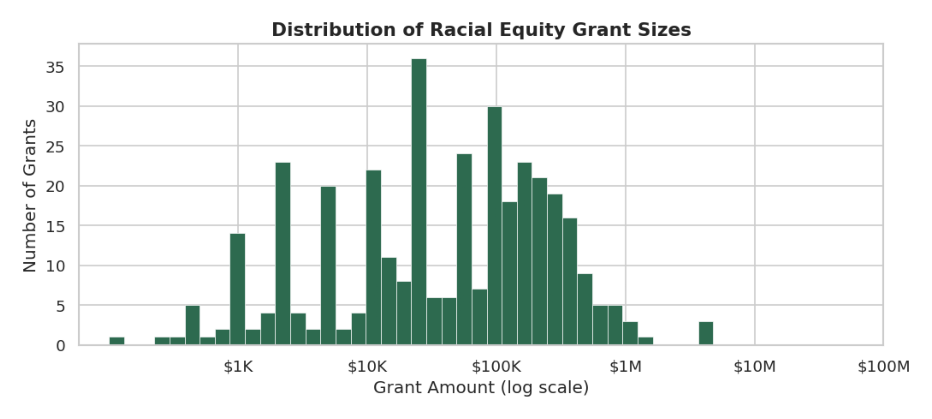

,bucket,grants,dollars_m
0,1 <$10K,86,0.25
1,2 $10K-50K,90,1.94
2,3 $50K-250K,125,15.90
3,4 $250K-1M,51,22.39
4,5 $1M+,7,18.38


In [7]:
p = PROC / 'fig_grant_size_dist.png'
if p.exists():
    plt.figure(figsize=(9, 4)); plt.imshow(mpimg.imread(p)); plt.axis('off'); plt.show()

pd.read_sql("""
    SELECT CASE
        WHEN grant_amount < 10000   THEN '1 <$10K'
        WHEN grant_amount < 50000   THEN '2 $10K-50K'
        WHEN grant_amount < 250000  THEN '3 $50K-250K'
        WHEN grant_amount < 1000000 THEN '4 $250K-1M'
        ELSE '5 $1M+'
    END AS bucket, COUNT(*) AS grants, ROUND(SUM(grant_amount)/1e6,2) AS dollars_m
    FROM grants WHERE is_racial_equity=1 GROUP BY bucket ORDER BY bucket
""", conn)

## Methodology & limitations

- **Keyword classification is a lower bound.** Grants with vague purpose text ("general support")
  are not flagged. Candid's full method also uses grantee mission and population codes; we
  replicate only the description-based component.
- **Single IRS release.** Results come from one ~400 MB chunk of the 2020 e-file release
  (fiscal years ~2018–2019). Funder/geography/issue patterns are sample-specific. Loading more
  release-year chunks (Notebook 01) broadens coverage and enables the pre/post-2020 time series.
- **No recipient EINs.** 990-PF grant schedules list recipient name + address only, so recipient
  NTEE codes and leadership demographics are out of reach until the Candid integration is live.
- **Paper filers excluded.** Only e-filed returns are in the IRS XML data.

## Future directions

1. Load multiple IRS release years for a genuine pre/post-2020 longitudinal analysis.
2. Add the Candid Premier + Demographics APIs (recipient EINs, NTEE, leadership diversity).
3. Normalize grant dollars per-capita by state using Census population.
4. Validate the keyword classifier against a hand-labeled sample.

---
*Built with Claude Code. Data: IRS 990-PF e-file (public domain); ProPublica Nonprofit Explorer API.*